In [ ]:
# Layout configuration now comes directly from lib.contour_tree_visualization
import lib.contour_tree_visualization as ctv

ENABLE_LAYOUT_RESOLUTION_IMPROVEMENT = True
RESOLUTION_SIGMA_SCALE = 0.5

print(
    "Using library-default contour_tree_layout pipeline "
    f"(resolution_remap={ENABLE_LAYOUT_RESOLUTION_IMPROVEMENT}, sigma_scale={RESOLUTION_SIGMA_SCALE})."
)


Using library-default contour_tree_layout pipeline (resolution_remap=True, sigma_scale=0.5).


# Uncertainty Visualization for Approximated Barycenter of Contour Trees

Accompanies the paper *Uncertainty Visualization for Approximated Barycenter of Contour Trees Based on Partial Optimal Transport* (Mingzhe Li, Fangfei Lan, Gunther Weber, Bei Wang).


## Goal

Compute an approximated barycenter of a family of contour trees with partial fused Gromov–Wasserstein (FGW) transport, export couplings and layouts, and prepare data for the metro-map uncertainty visualization.

Pipeline:
1. Load contour trees from `treeNodes_*.txt` / `treeEdges_*.txt` under `data/<dataset_name>/`.
2. Build relation matrices (adjacency or shortest path).
3. Compute partial FGW barycenter and input–barycenter couplings.
4. Export to `barycenter_export/<dataset_name>/`.
5. Run `metro_viz/prepare_data.py`, then serve `metro_viz/` for interactive visualization.


In [2]:
# Imports (align with tushar_example.ipynb as needed)
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# POT / repo modules
import ot
from lib.gromov import partial_fused_gromov_ver1, fused_gromov_wasserstein, PFGW_dist_with_penalty
from lib.gromov_barycenter import *
from lib.opt import *

# Optional: local helper functions can be added below


In [ ]:
# 1) Contour tree loading
from pathlib import Path
from lib.read_contour_tree import read_txt


def load_contour_trees(dataset_name, data_root="data"):
    """
    Load contour trees from:
      data/{dataset_name}/treeNodes_monoMesh_*.txt
      data/{dataset_name}/treeEdges_monoMesh_*.txt
    """
    data_dir = Path(data_root) / dataset_name
    node_files = sorted(data_dir.glob("treeNodes_monoMesh_*.txt"))
    if not node_files:
        raise FileNotFoundError(f"No node files found in {data_dir}")

    trees = []
    for node_file in node_files:
        edge_file = Path(str(node_file).replace("Nodes", "Edges"))
        if not edge_file.exists():
            raise FileNotFoundError(f"Missing edge file for {node_file.name}")
        T = read_txt(str(node_file), str(edge_file))
        trees.append(T)

    return trees


def load_contour_trees_at_timestep(data_dir, time_step):
    """
    Load contour trees from all ensembles at one temporal *order index*.

    Files are named like treeNodes_monoMesh$A$_$B$.txt, where B can be
    integer or float timestamp text. We sort unique B values numerically and
    use `time_step` as the index into that ordered list.
    """
    data_dir = Path(data_dir)
    node_files_all = sorted(data_dir.glob("treeNodes_monoMesh*_*.txt"))
    if not node_files_all:
        raise FileNotFoundError(f"No node files found in {data_dir}")

    def _time_token(node_path):
        stem = node_path.stem  # treeNodes_monoMeshA_B
        return stem.rsplit("_", 1)[-1]

    unique_tokens = sorted({_time_token(p) for p in node_files_all}, key=float)
    if not unique_tokens:
        raise FileNotFoundError(f"Could not parse timestamps in {data_dir}")

    idx = int(time_step)
    if idx < 0:
        idx += len(unique_tokens)
    if idx < 0 or idx >= len(unique_tokens):
        raise IndexError(
            f"time_step index {time_step} out of range [0, {len(unique_tokens)-1}]"
        )

    ts_str = unique_tokens[idx]
    pattern = f"treeNodes_monoMesh*_{ts_str}.txt"
    node_files = sorted(data_dir.glob(pattern))
    if not node_files:
        raise FileNotFoundError(f"No node files found in {data_dir} matching {pattern}")
    print(node_files)
    trees = []
    for node_file in node_files:
        edge_file = Path(str(node_file).replace("Nodes", "Edges"))
        if not edge_file.exists():
            raise FileNotFoundError(f"Missing edge file for {node_file.name}")
        T = read_txt(str(node_file), str(edge_file))
        trees.append(T)

    return trees


# Load contour trees at a fixed time step from all ensembles
dataset_name = "VortexStreet_eps1.0"
data_dir = f"data/{dataset_name}"
# 4 for HeatedFlow3D; 6 for HeatedFlow2D; 0 for VortexStreet
time_step = 0  # fix time step; load all ensembles at this step 
balanced_distribution = False

Gs = load_contour_trees_at_timestep(data_dir, time_step)
print(f"Loaded {len(Gs)} contour trees at time_step={time_step}")
print("Node counts:", [G.number_of_nodes() for G in Gs])



[WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh10_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh11_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh12_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh13_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh14_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh15_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh16_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh17_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh18_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh19_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh1_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh20_007.txt'), WindowsPath('data/HeatedFlowEnsemble_eps3.0/treeNodes_monoMesh21_007.txt'), WindowsPath(

In [5]:
import importlib
import lib.contour_tree_visualization as ctv
import lib.color_transfer as ct

importlib.reload(ctv)
importlib.reload(ct)

# branches, root = ctv.get_branch_decomposition(Gs[0])
# print(ctv.format_branch_decomposition(branches))

ctv.plot_input_trees(
    Gs,
    dataset_name=dataset_name,
    time_step=time_step,
    node_color_mode="type",
)

[<Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 1'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 2'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 3'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 4'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 5'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 6'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 7'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 8'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 9'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps3.0, time_step=6) 10'}>,
 <Axes: title={'center': 'Input contour trees (HeatedFlowEnsemble_eps

In [ ]:
# 3) Relation matrices

def relation_matrix(
    G,
    kind="weighted_adjacency",
    *,
    nodelist=None,
):
    """
    Build relation matrices for graphs.

    kind:
      - "adjacency": adjacency matrix (0/1)
      - "weighted_adjacency": adjacency matrix with edge weights
      - "shortestpath": shortest-path distances
      - "laplacian": heat kernel exp(-tau * L) where L is from adjacency or
        from a shortest-path derived affinity matrix.

    laplacian_base:
      - "adjacency": Laplacian from adjacency weights
      - "shortestpath": Laplacian from affinity built off shortest-path distances

    sp_affinity:
      - "exp": A_ij = exp(-D_ij / sigma)
      - "inverse": A_ij = 1 / (D_ij + eps)
    """
    if nodelist is None:
        nodelist = list(G.nodes())

    kind = kind.lower()
  
    if kind == "adjacency":
        A = nx.to_numpy_array(G, nodelist=nodelist, dtype=float, weight=None)
        A = (A != 0).astype(float)
        return A, nodelist

    if kind == "weighted_adjacency":
        # use edge weights if present; default to 1.0 when missing
        A = nx.to_numpy_array(G, nodelist=nodelist, dtype=float, weight="weight")
        return A, nodelist

    if kind == "shortestpath":
        # Edge weight = |height(u)-height(v)|; non-adjacent = shortest path sum. relation_rescale handles global scaling.
        G_use = G
        # if all(G.nodes[n].get("height") is not None for n in nodelist):
        #     G_use = G.copy()
        #     for u, v in G_use.edges():
        #         h_diff = abs(G_use.nodes[u]["height"] - G_use.nodes[v]["height"])
        #         G_use.edges[u, v]["weight"] = h_diff
        D = nx.floyd_warshall_numpy(G_use, nodelist=nodelist, weight="weight")
        return D, nodelist

    raise NotImplementedError
    return None, None



### 3.1) Early export: input trees for metro_viz (before barycenter)

Writes `barycenter_export/<dataset_name>/input_trees/tree_*.json` (viz layout, segments, **branches**) via `contour_tree_layout`. Run after loading **`Gs`** to refresh metro viz without the barycenter solver.

If **`idx_list`** already exists (after running section 4), the same indices and `tree_{s:02d}.json` ordering as couplings are used; otherwise all `len(Gs)` graphs are exported.


In [7]:
# 3.1) Export input tree JSON for metro_viz (no barycenter required)
import os
import json

from lib.contour_tree_visualization import contour_tree_layout, edge_segment_node_ids

save_keyword = "_balanced_distribution" if balanced_distribution else ""
SAVE_DIR = os.path.join("barycenter_export", dataset_name + save_keyword)
os.makedirs(SAVE_DIR, exist_ok=True)

input_trees_dir = os.path.join(SAVE_DIR, "input_trees")
os.makedirs(input_trees_dir, exist_ok=True)

# try:
#     _idx_export = idx_list
# except NameError:
_idx_export = list(range(len(Gs)))
n_saved = len(_idx_export)

for s in range(n_saved):
    G_s = Gs[_idx_export[s]]
    edges_s = [[int(u), int(v)] for u, v in G_s.edges()]
    nodes_s = sorted([int(n) for n in G_s.nodes()])
    heights_s = {str(int(n)): float(G_s.nodes[n].get("height", 0)) for n in G_s.nodes()}
    types_s = {str(int(n)): int(G_s.nodes[n].get("type", 1)) for n in G_s.nodes()}
    xs_s = {str(int(n)): float(G_s.nodes[n]["x"]) for n in G_s.nodes() if "x" in G_s.nodes[n]}
    ys_s = {str(int(n)): float(G_s.nodes[n]["y"]) for n in G_s.nodes() if "y" in G_s.nodes[n]}
    zs_s = {str(int(n)): float(G_s.nodes[n]["z"]) for n in G_s.nodes() if "z" in G_s.nodes[n]}
    pos_viz, branches_viz, edge_segments_viz = contour_tree_layout(
        G_s,
        root=None,
        width=1.0,
        height_scale=1.0,
        apply_resolution_improvement=True,
        resolution_sigma_scale=0.5,
    )
    viz_pos = {
        str(int(n)): [float(pos_viz[n][0]), float(pos_viz[n][1])]
        for n in G_s.nodes()
    }
    viz_edge_segments = [
        [[float(x), float(y)] for x, y in seg] for seg in edge_segments_viz
    ]
    seg_node_ids = edge_segment_node_ids(G_s, branches_viz)
    viz_segment_node_ids = [[int(n) for n in row] for row in seg_node_ids]
    assert len(viz_edge_segments) == len(viz_segment_node_ids), (
        f"input {s}: edge segments / node-id lists length mismatch"
    )
    branches_viz_json = [
        {
            "nodes": [int(n) for n in b["nodes"]],
            "parentBranch": int(b["parent_branch"]),
            "mode": b["mode"],
            "depth": int(b["depth"]),
        }
        for b in branches_viz
    ]
    tree_data = {
        "nodes": nodes_s,
        "edges": edges_s,
        "heights": heights_s,
        "types": types_s,
        "xs": xs_s,
        "ys": ys_s,
        "zs": zs_s,
        "vizPos": viz_pos,
        "vizEdgeSegments": viz_edge_segments,
        "vizSegmentNodeIds": viz_segment_node_ids,
        "branches": branches_viz_json,
    }
    with open(os.path.join(input_trees_dir, f"tree_{s:02d}.json"), "w") as f:
        json.dump(tree_data, f)

print(f"Saved {n_saved} input trees to {input_trees_dir}/ (run before barycenter; safe to re-run)")


Saved 23 input trees to barycenter_export\HeatedFlowEnsemble_eps3.0\input_trees/ (run before barycenter; safe to re-run)


In [ ]:
# 4) Barycenter computation (demo for Gs[idx_0] and Gs[idx_1])
import importlib
import lib.gromov as gromov
import lib.gromov_barycenter as gromov_barycenter
importlib.reload(gromov)
importlib.reload(gromov_barycenter)

# Re-import the functions you use in the notebook
from lib.gromov import partial_fused_gromov_ver1, fused_gromov_wasserstein, GW_dist, PFGW_dist_with_penalty
from lib.gromov_barycenter import *
from ot.utils import dist
from tqdm import tqdm

idx_list = list(range(len(Gs)))

# --- Relation matrix selection ---
relation_kind = "shortestpath"                 # "adjacency" | "weighted_adjacency" | "shortestpath" | "laplacian"
laplacian_base = "adjacency"          # "adjacency" | "shortestpath"
laplacian_normalization = "none"      # "none" | "sym" | "rw"
tau = 1.0                              # heat kernel time for laplacian
sp_weighted = False                    # use weighted edges for shortest paths
sp_affinity = "exp"                   # "exp" | "inverse" (if laplacian_base="shortestpath")
sp_sigma = None                        # scale for exp affinity; None -> median distance
relation_rescale = 1.0
relation_offset = 0.0

if relation_kind == "weighted_adjacency":
    WAs = [relation_matrix(Gs[idx], kind=relation_kind)[0] for idx in idx_list]
    min_nonzeros = [np.min(WA[WA > 0]) for WA in WAs]
    max_nonzeros = [np.max(WA[WA > 0]) for WA in WAs]
    relation_rescale = 1.0 / (max(max_nonzeros) - min(min_nonzeros))
    relation_offset = min(min_nonzeros)
elif relation_kind == "shortestpath":
    Ds = [relation_matrix(Gs[idx], kind=relation_kind)[0] for idx in idx_list]
    max_dists = [np.nanmax(D[np.isfinite(D) & (D > 0)]) if np.any(np.isfinite(D) & (D > 0)) else 1.0 for D in Ds]
    max_d = max(max_dists) if max_dists else 1.0
    relation_rescale = 1.0 / max_d if max_d > 0 else 1.0
    relation_offset = 0.0

# --- Barycenter solver selection ---
use_partial = True                     # True: partial GW barycenter; False: GW barycenter
n_graphs = len(idx_list)
n_nodes_list = [Gs[idx].number_of_nodes() for idx in idx_list]
N_min = max(n_nodes_list)
N_max = N_min + 2 * n_graphs           # N_center in [max|V_i|, max|V_i|+2N]

# --- N_center tuning (contour trees often have even # of nodes) ---
tune_N_center = False                   # True: loop over N_center candidates, pick best by PFGW loss
N_center_even_only = True               # True: try only even N_center (typical for contour trees)
if tune_N_center:
    N_center_candidates = [n for n in range(N_min, N_max + 1) if (not N_center_even_only) or (n % 2 == 0)]
    if not N_center_candidates:
        N_center_candidates = [N_min]
    print("N_center candidates:", N_center_candidates)
else:
    N_center_candidates = [N_min]

lambdas = np.ones(n_graphs, dtype=float) / n_graphs  # weights for each input contour tree
max_iter = 100                         # max iterations for barycenter solver
bary_tol = 1e-6                        # convergence tolerance on barycenter updates

random_state = 0                          # reproducibility for initialization
lambda_penalty = 0.4                      # partial GW penalty (None -> default per-graph max(C))
alpha_fgw = 1 / N_min                     # PFGW trade-off: (1-alpha)*feature + alpha*structure
print(lambda_penalty, alpha_fgw)

# --- Coupling restarts during barycenter optimization ---
gw_restarts = 10                       # number of restarts per GW coupling (per graph, per iteration)
gw_seed_start = 0                      # seed offset for coupling restarts

# Build relation matrices
Cs = []
nodes_list = []
for idx in idx_list:
    G = Gs[idx]
    C_idx, nodes_idx = relation_matrix(
        G,
        kind=relation_kind,
        laplacian_base=laplacian_base,
        laplacian_normalization=laplacian_normalization,
        tau=tau,
        sp_weighted=sp_weighted,
        sp_affinity=sp_affinity,
        sp_sigma=sp_sigma,
    )
    if relation_kind == "weighted_adjacency":
        edge_mask = C_idx > 0
        C_idx[edge_mask] = (C_idx[edge_mask] - relation_offset) * relation_rescale
        C_idx[edge_mask] += 1
    elif relation_kind == "shortestpath":
        # Normalize distances to [0,1] for GW scale consistency
        finite = np.isfinite(C_idx) & (C_idx > 0)
        if np.any(finite):
            C_idx[finite] = C_idx[finite] * relation_rescale
    Cs.append(C_idx)
    nodes_list.append(nodes_idx)

# --- Node attribute features for PFGW (M matrix) ---
# attribute_mode: "full" | "height_type" | "euclidean_type"
# "full": fuses euclidean + height + type for full contour tree reconstruction
# "height_type": height [0,1] + one-hot types
# "euclidean_type": (x,y,z) normalized by domain size + one-hot types
attribute_mode = "full"             # "full" | "height_type" | "euclidean_type"

# Collect all values for normalization
all_x, all_y, all_z, all_heights, all_types = [], [], [], [], []
for idx in idx_list:
    for n in Gs[idx].nodes():
        all_x.append(Gs[idx].nodes[n]["x"])
        all_y.append(Gs[idx].nodes[n]["y"])
        all_z.append(Gs[idx].nodes[n]["z"])
        all_heights.append(Gs[idx].nodes[n]["height"])
        all_types.append(Gs[idx].nodes[n]["type"])
min_x, max_x = min(all_x), max(all_x)
min_y, max_y = min(all_y), max(all_y)
min_z, max_z = min(all_z), max(all_z)
h_min, h_max = min(all_heights), max(all_heights)
domain_size = np.sqrt((max_x - min_x)**2 + (max_y - min_y)**2 + (max_z - min_z)**2)
domain_size = domain_size if domain_size > 0 else 1.0
h_range = h_max - h_min if h_max > h_min else 1.0
unique_types = sorted(set(all_types))
type_to_idx = {t: i for i, t in enumerate(unique_types)}
n_types = len(unique_types)
type_scale = 1 / np.sqrt(2)      # so (type_scale)^2 + (type_scale)^2 = 2^2 for different types

Ys = []
for s in range(len(idx_list)):
    nodes_s = nodes_list[s]
    G_s = Gs[idx_list[s]]
    parts = []
    if attribute_mode in ("full", "euclidean_type"):
        coords = np.array([[(G_s.nodes[n]["x"] - min_x) / domain_size,
                           (G_s.nodes[n]["y"] - min_y) / domain_size,
                           (G_s.nodes[n]["z"] - min_z) / domain_size] for n in nodes_s], dtype=float)
        parts.append(coords)
    if attribute_mode in ("full", "height_type"):
        heights_s = np.array([(G_s.nodes[n]["height"] - h_min) / h_range for n in nodes_s], dtype=float)
        parts.append(heights_s.reshape(-1, 1))
    onehot = np.zeros((len(nodes_s), n_types), dtype=float)
    for i, n in enumerate(nodes_s):
        onehot[i, type_to_idx[G_s.nodes[n]["type"]]] = type_scale
    parts.append(onehot)
    Ys.append(np.column_stack(parts))

# Distributions on input graphs (uniform over nodes)
# Note: No guarantee that the sum of each p is equal
if balanced_distribution:
    ps = [np.ones(C.shape[0]) / C.shape[0] for C in Cs]
else:
    ps = [np.ones(C.shape[0]) for C in Cs]
print(ps)

best_over_N = None  # best {N_center, C_center, X_center, log, cost} across N_center candidates

for N_center in tqdm(N_center_candidates, desc="N_center tuning"):
    # Distribution on barycenter nodes (depends on N_center)
    if balanced_distribution:
        p = np.ones(N_center) / N_center
    else:
        p = np.ones(N_center) 
    print(p)

    if use_partial:
        # Partial GW barycenter (penalizes mass removal)
        Lambda_list = None if lambda_penalty is None else [lambda_penalty] * len(idx_list)

        # --- Multi-start init without extra total iterations ---
        init_restarts = 10   # number of initializations to try
        init_iters = max_iter // (init_restarts + 1)  # keep total iters ~ max_iter
        remaining_iters = max_iter - init_restarts * init_iters + 20

        def _pfgw_total_cost(C_tmp, X_tmp, log_tmp, debug=False):
            total = 0.0
            for s in range(len(Cs)):
                M_s = dist(X_tmp, Ys[s])
                d, penalty = PFGW_dist_with_penalty(M_s, C_tmp, Cs[s], log_tmp["T"][s], p, ps[s], Lambda_list[s], alpha=alpha_fgw)
                total += lambdas[s] * (d + penalty)
            return float(total)

        if init_restarts <= 1 or init_iters <= 0:
            C_center, X_center, log = pfgw_barycenters(
                N=N_center,
                Ys=Ys,
                Cs=Cs,
                ps=ps,
                p=p,
                Lambda_list=Lambda_list,
                lambdas=lambdas,
                alpha=alpha_fgw,
                max_iter=max_iter,
                tol=bary_tol,
                log=True,
                random_state=random_state,
                gw_restarts=gw_restarts,
                gw_seed_start=gw_seed_start,
                debug=not tune_N_center,
            )
        else:
            best = None
            for r in range(init_restarts):
                seed = random_state + r
                C_tmp, X_tmp, log_tmp = pfgw_barycenters(
                    N=N_center,
                    Ys=Ys,
                    Cs=Cs,
                    ps=ps,
                    p=p,
                    Lambda_list=Lambda_list,
                    lambdas=lambdas,
                    alpha=alpha_fgw,
                    max_iter=init_iters,
                    tol=bary_tol,
                    log=True,
                    random_state=seed,
                    gw_restarts=gw_restarts,
                    gw_seed_start=gw_seed_start,
                    debug=False,
                )
                cost = _pfgw_total_cost(C_tmp, X_tmp, log_tmp)
                if (best is None) or (cost < best["cost"]):
                    best = {"seed": seed, "cost": cost, "C": C_tmp, "X": X_tmp}
            if np.any(np.isnan(best["C"])):
                print("NaN values found in C! No implementation to replace these values yet. "
                        "We discard the best C and only reuse the best initial states!")
                best["C"] = None
                best["X"] = None

            # continue from best initialization
            C_center, X_center, log = pfgw_barycenters(
                N=N_center,
                Ys=Ys,
                Cs=Cs,
                ps=ps,
                p=p,
                Lambda_list=Lambda_list,
                lambdas=lambdas,
                alpha=alpha_fgw,
                max_iter=max(1, remaining_iters),
                tol=bary_tol,
                log=True,
                init_C=best["C"],
                init_X=best["X"],
                random_state=best["seed"],
                gw_restarts=gw_restarts,
                gw_seed_start=gw_seed_start,
                debug=not tune_N_center,
            )
    else:
        # Standard GW barycenter
        C_center, log = gromov_barycenters(
            N=N_center,
            Cs=Cs,
            ps=ps,
            p=p,
            lambdas=lambdas,
            max_iter=max_iter,
            tol=bary_tol,
            log=True,
            random_state=random_state,
        )

    # Evaluate and track best N_center
    if use_partial:
        X_center = log.get("X", X_center)
        cost = _pfgw_total_cost(C_center, X_center, log)
        # Debug: distance and penalty per input for each N_center
        if tune_N_center:
            total_dist, total_pen = 0.0, 0.0
            for s in range(len(idx_list)):
                M_s = dist(X_center, Ys[s])
                d, penalty = PFGW_dist_with_penalty(M_s, C_center, Cs[s], log["T"][s], p, ps[s], Lambda_list[s], alpha=alpha_fgw)
                total_dist += lambdas[s] * d
                total_pen += lambdas[s] * penalty
                print(f"  N_center={N_center} input {s}: distance={d:.6e}, penalty={penalty:.6e} => total={d+penalty:.6e}")
            print(f"N_center={N_center} cost={cost:.6e} (dist={total_dist:.6e}, penalty={total_pen:.6e})")
    else:
        cost = sum(lambdas[s] * GW_dist(C_center, Cs[s], log["T"][s]) for s in range(n_graphs))
        if tune_N_center:
            print(f"N_center={N_center} cost={cost:.6e}")
    if (best_over_N is None) or (cost < best_over_N["cost"]):
        entry = {"N_center": N_center, "C_center": C_center, "log": log, "p": p, "cost": cost}
        if use_partial:
            entry["X_center"] = X_center
        best_over_N = entry
        # if tune_N_center:
        #     print(f"N_center={N_center} cost={cost:.6e} (new best)")

# Use best result
N_center = best_over_N["N_center"]
C_center = best_over_N["C_center"]
X_center = best_over_N.get("X_center")  # PFGW barycenter features (height)
log = best_over_N["log"]
p = best_over_N["p"]
if tune_N_center:
    print(f"Best N_center={N_center} with PFGW total cost={best_over_N['cost']:.6e}")

print("Barycenter matrix shape:", C_center.shape)


0.4 0.029411764705882353
[array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

N_center tuning:   0%|          | 0/1 [00:00<?, ?it/s]

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


c:\Users\mingz\anaconda3\envs\pOTbarycenter\Lib\site-packages\ot\bregman\_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


pfgw barycenter starts...
iter 0 err 0.12310675702577384
iter 1 err 0.08126875910116235
iter 2 err 0.02911232020550892
iter 3 err 0.021091977661228372
iter 4 err 0.013301185123328601


N_center tuning: 100%|██████████| 1/1 [14:19<00:00, 859.98s/it]

iter 5 err 0.0
Barycenter matrix shape: (34, 34)


#### 3.1.1) Runtime records

HeatedFlow3D_eps3.0: 38.97s, 42.09s, 34.36s, 34.47s

Node counts: [62, 54, 60, 54, 58, 68, 64, 54, 58, 46]

HeatedFlow2D_eps3.0: 132.89s, 115.91s

Node counts: [30, 28, 26, 26, 32, 32, 26, 26, 26, 26, 24, 28, 32, 28, 34, 32, 28, 24, 32, 30, 32, 26, 30]

VortexStreet_eps1.0: 57.09s, 50.90s, 59.29s

Node counts: [59, 61, 59, 60, 59, 59, 59, 56, 61, 61]

### 3.2) Verification

We need to do a quick verification on the coupling matrix T (log['T']). 

Entries in T should be mostly filled with 0s and only a few positive entries per row/column.

If all entries in T are identical and near zero (e.g., 1e-10 or even less), this means lambda_penalty is too low. We need to modify lambda penalty in 3.1) and rerun the experiment.

In [ ]:
print(log['T'])

[array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.33333333e-17, 3.33333333e-17, 3.33333333e-17, ...,
        3.33333333e-17, 3.33333333e-17, 3.33333333e-17],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]), array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000

In [ ]:
# 4.1) Inspect barycenter relation matrix
# Note: C_center is the relation matrix in the same type as `relation_kind`.
print("relation_kind:", relation_kind)
print("C_center shape:", C_center.shape)
# print(C_center)
# print(np.sum(C_center, axis=0))
# print(np.sum(C_center, axis=1))

if relation_kind in ("adjacency", "weighted_adjacency"):
    if np.any(np.isnan(C_center)):
        C_center[np.isnan(C_center)] = 0
        print("update adjacency to replace NaN with 0 (if any)...")
elif relation_kind == "shortestpath":
    if np.any(np.isnan(C_center)):
        C_center[np.isnan(C_center)] = np.inf
        print("shortestpath: replaced NaN with inf")

relation_kind: shortestpath
C_center shape: (34, 34)
[[0.00000000e+00 3.00218065e-01 2.22735550e-01 ... 7.62369041e-01
  7.63296844e-01 8.16587676e-01]
 [3.00218065e-01 3.29997728e-31 7.54796503e-02 ... 6.29414357e-01
  6.36149986e-01 6.84313432e-01]
 [2.22735550e-01 7.54796503e-02 7.70505944e-32 ... 5.44827709e-01
  5.35980127e-01 6.01553796e-01]
 ...
 [7.62369041e-01 6.29414357e-01 5.44827709e-01 ... 1.94825710e-31
  7.37435501e-02 3.33698211e-01]
 [7.63296844e-01 6.36149986e-01 5.35980127e-01 ... 7.37435501e-02
  7.17828166e-31 3.36948207e-01]
 [8.16587676e-01 6.84313432e-01 6.01553796e-01 ... 3.33698211e-01
  3.36948207e-01 0.00000000e+00]]


In [ ]:
# This shows the one-hot vector for critical point types
# The corresponding dimension of the type should be 1/sqrt(2), and the other two dimensions should be near 0
print(X_center[:, -3:])

[[0.00000000e+00 0.00000000e+00 7.07106781e-01]
 [2.12863208e-16 2.99956488e-16 7.07106781e-01]
 [4.87013491e-17 7.07106781e-01 3.14735450e-17]
 [6.34942750e-17 7.07106781e-01 4.22875469e-17]
 [7.07106781e-01 4.90215374e-17 2.49527105e-17]
 [0.00000000e+00 0.00000000e+00 7.07106781e-01]
 [5.60593292e-17 7.07106781e-01 4.90039101e-17]
 [0.00000000e+00 7.07106781e-01 0.00000000e+00]
 [1.39969031e-16 7.07106781e-01 1.04585940e-16]
 [0.00000000e+00 0.00000000e+00 7.07106781e-01]
 [7.07106781e-01 7.48703882e-16 3.70685282e-16]
 [0.00000000e+00 7.07106781e-01 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 7.07106781e-01]
 [7.07106781e-01 0.00000000e+00 0.00000000e+00]
 [3.04081817e-17 7.07106781e-01 2.64258496e-17]
 [7.07106781e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.07106781e-01 0.00000000e+00]
 [0.00000000e+00 7.07106781e-01 0.00000000e+00]
 [7.07106781e-01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 7.07106781e-01 0.00000000e+00]
 [2.05902221e-16 7.07106781e-01 1.417356

Barycenter graph: nodes = 34 , edges = 561
Is connected before adding not legit edges: True
Number of edges before adding not legit edges: 33
Number of nodes before adding not legit edges: 34
Barycenter graph (after MST): nodes = 30 , edges = 29
(5, 25): weight = 0.5036714928682351, height diff = 0.3503816035805627
(11, 25): weight = 0.35814911640347025, height diff = 0.21069526598465477
Contour tree validity: {'type_violations': 0, 'extrema_saddle_violations': 0, 'weight_violations': 2, 'two_degree_nodes': 0, 'type_value_inconsistencies': 0}
Layout diagnostics: {'n_branches': 17, 'n_groups': 14, 'n_coarse_edges': 13, 'group_intersection_initial': 289039.0, 'group_intersection_final': 289019.0, 'crossing_initial': 289039.0, 'crossing_final': 289019.0, 'n_dag_edges': 68, 'n_constraints': 68, 'n_unique_branch_x': 17, 'group_order': [13, 9, 15, 14, 4, 6, 16, 11, 1, 0, 2, 3, 5, 7]}
Branch decomposition:
  [0] trunk: 13-7-31-29-16-11-25-5
  [1] saddle 7 -> leaf 15: 7-17-15
  [2] saddle 7 ->

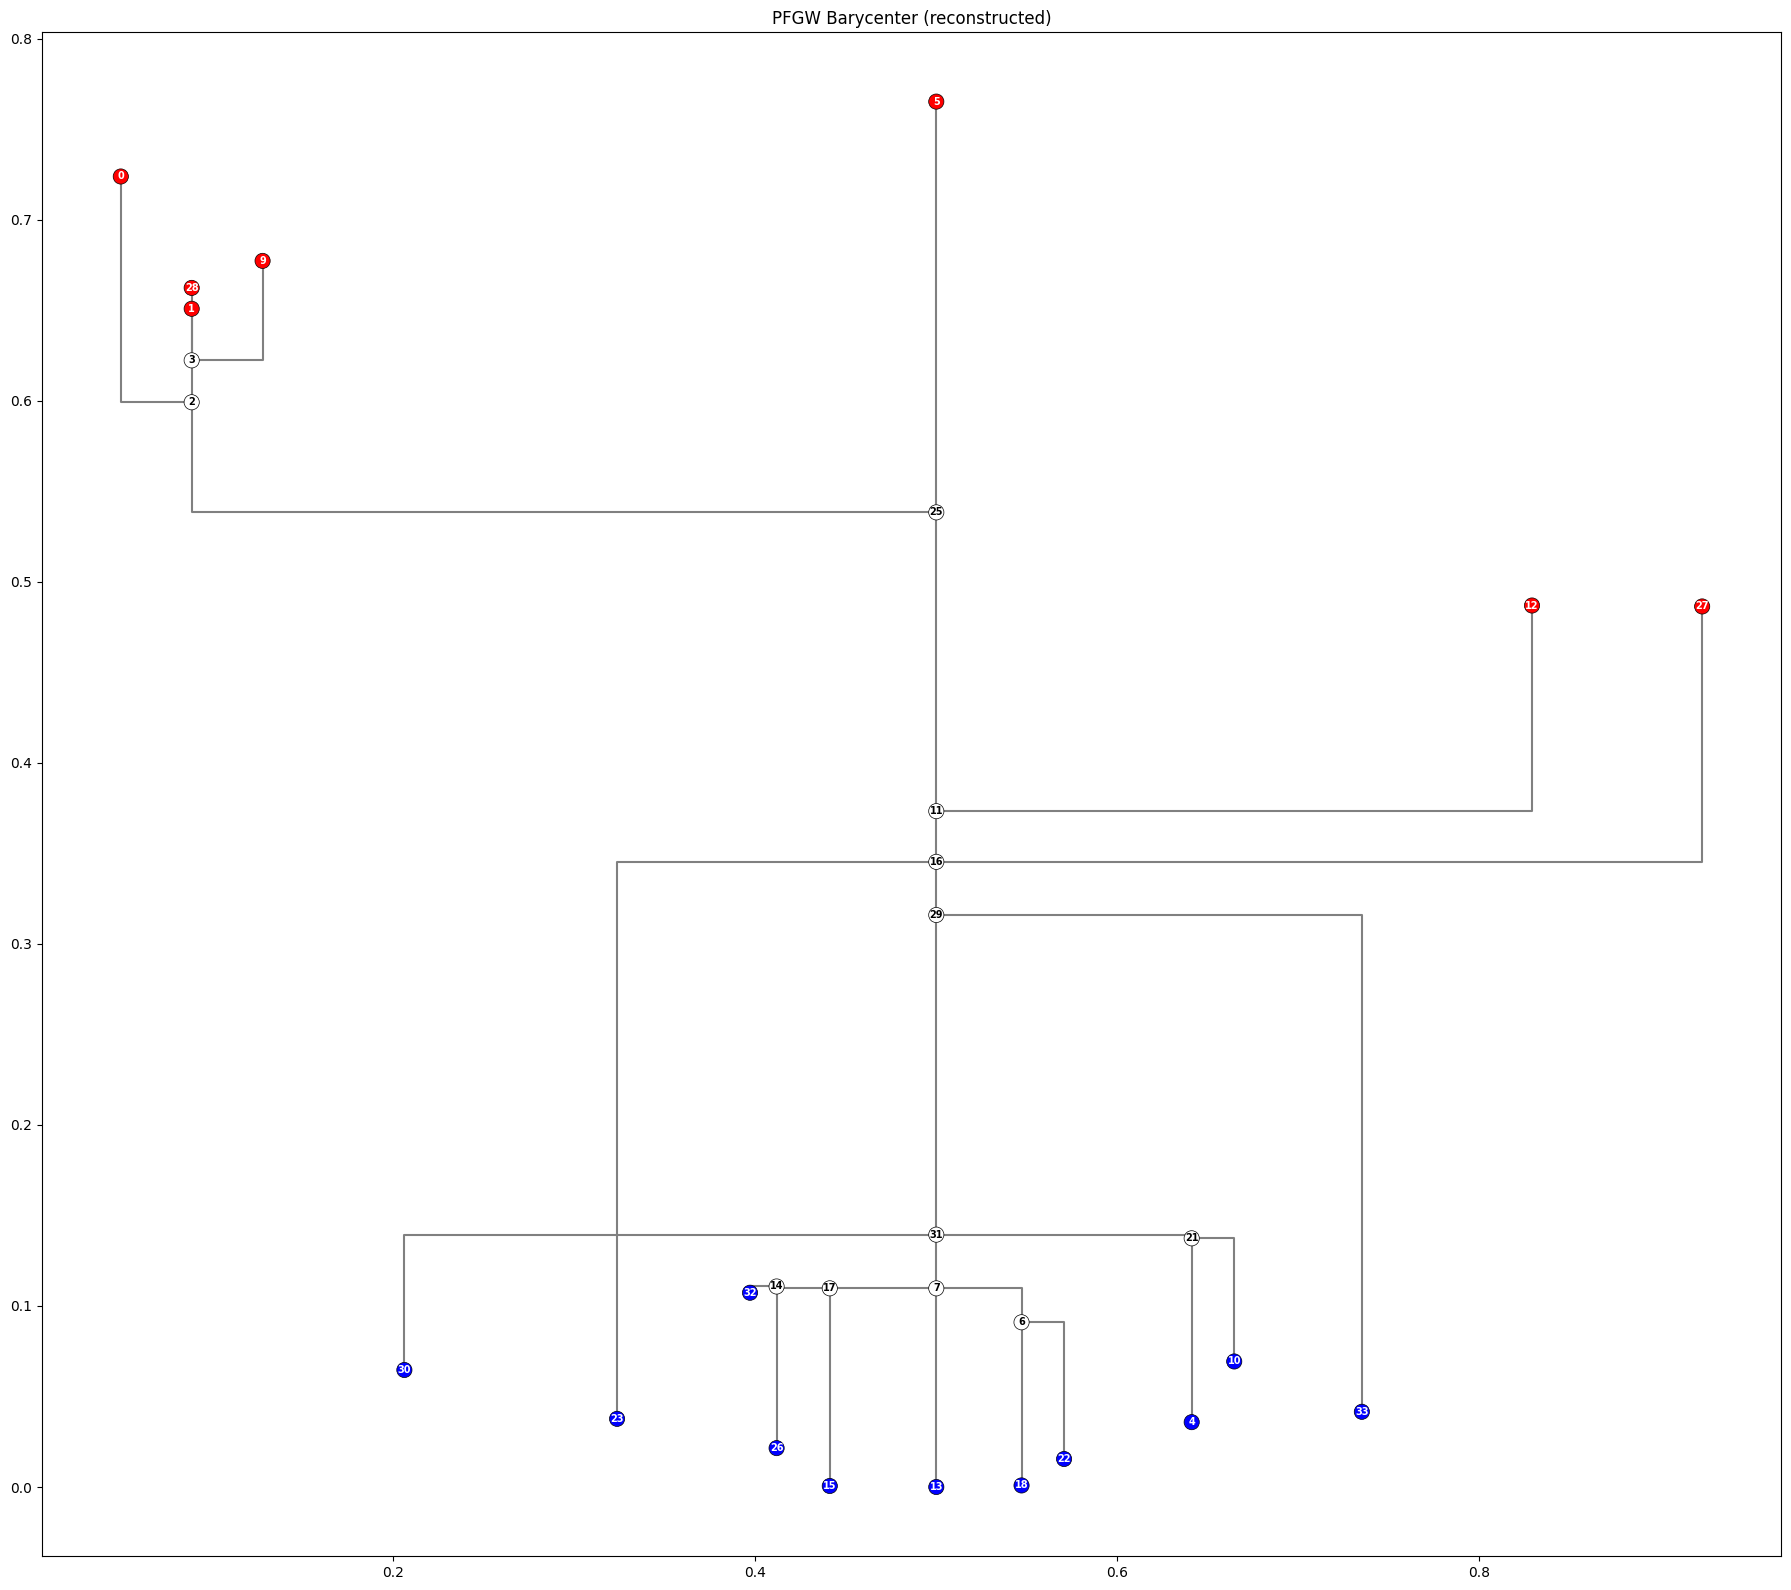

In [21]:
# 4.2) FGW barycenter: construct graph from X_center and C_center, verify, visualize
# Uses lib/contour_tree_visualization.plot_contour_tree only (no monkey patch).
import importlib
import lib
importlib.reload(lib.contour_tree_visualization)

import logging
# logging.basicConfig(level=logging.INFO)
os.environ["CONTOUR_TREE_LAYOUT_DEBUG"] = "0"

from lib.contour_tree_visualization import (
    reconstruct_graph_from_fgw_barycenter,
    postprocess_pfgw_barycenter,
    validate_contour_tree_structure,
    get_branch_decomposition,
    format_branch_decomposition,
    diagnose_branch_decomposition,
    contour_tree_layout_diagnostics,
    plot_contour_tree,
)

EDGE_THRESHOLD = 0.5  # ignore C_center entries below this
VALID_TYPES = {0, 1, 2}  # local minima, saddles, local maxima

if X_center is None:
    print("X_center is None (GW barycenter without features). Skipping FGW reconstruction.")
    print("Run with use_partial=True for FGW barycenter visualization.")
    # Fallback: build minimal graph for Section 5 (placeholder heights)
    C_arr = np.asarray(C_center, dtype=float)
    if relation_kind == "shortestpath":
        C_arr = np.nan_to_num(C_arr, nan=np.inf, posinf=np.inf)
    else:
        C_arr = np.nan_to_num(C_arr, nan=0.0)
    np.fill_diagonal(C_arr, 0.0)
    n = C_arr.shape[0]
    G_center = nx.Graph()
    for i in range(n):
        G_center.add_node(i, height=float(i) / max(n - 1, 1))
    for i in range(n):
        for j in range(i + 1, n):
            w = C_arr[i, j]
            if relation_kind == "shortestpath":
                add = np.isfinite(w) and w > 0
            else:
                add = w >= EDGE_THRESHOLD
            if add:
                G_center.add_edge(i, j, weight=float(w))
    if not nx.is_tree(G_center):
        if relation_kind == "shortestpath":
            G_center = nx.minimum_spanning_tree(G_center, weight="weight")
        else:
            G_center = nx.maximum_spanning_tree(G_center, weight="weight")
    # G_center = postprocess_pfgw_barycenter(G_center, relation_kind)
    print("Barycenter graph: nodes =", G_center.number_of_nodes(), ", edges =", G_center.number_of_edges())
    plot_contour_tree(
        G_center,
        title="GW Barycenter (fallback)",
        apply_resolution_improvement=True,
        resolution_sigma_scale=0.5,
    )
else:
    # 1) Construct graph from C_center and X_center (threshold=0.5)
    G_center_graph = reconstruct_graph_from_fgw_barycenter(
        C_center,
        X_center,
        attribute_mode=attribute_mode,
        unique_types=unique_types,
        min_x=min_x,
        max_x=max_x,
        min_y=min_y,
        max_y=max_y,
        min_z=min_z,
        max_z=max_z,
        h_min=h_min,
        h_range=h_range,
        domain_size=domain_size,
        threshold=EDGE_THRESHOLD,
        relation_kind=relation_kind,
    )
    print("Barycenter graph: nodes =", G_center_graph.number_of_nodes(), ", edges =", G_center_graph.number_of_edges())
    # 2) Postprocess: MST (min-ST for shortestpath, max-ST for adjacency)
    G_center = postprocess_pfgw_barycenter(G_center_graph, relation_kind=relation_kind, suppress_degree2_saddles=True)
    # 3) Print graph sizes and validate
    n_nodes = G_center.number_of_nodes()
    n_edges = G_center.number_of_edges()
    print("Barycenter graph (after MST): nodes =", n_nodes, ", edges =", n_edges)
    violations = validate_contour_tree_structure(
        G_center, valid_types=VALID_TYPES, height_weight_tol_rel=0.10
    )
    print("Contour tree validity:", violations)
    print("Layout diagnostics:", contour_tree_layout_diagnostics(G_center))
    # 4) Output branch decomposition and diagnose missing nodes
    try:
        branches, root = get_branch_decomposition(G_center)
        print(format_branch_decomposition(branches, root))
        print(diagnose_branch_decomposition(G_center, branches))
    except Exception as e:
        print("Branch decomposition failed:", e)
    # 5) Visualize with plot_contour_tree only
    plot_contour_tree(
        G_center,
        title="PFGW Barycenter (reconstructed)",
        node_color_mode="type",
        apply_resolution_improvement=True,
        resolution_sigma_scale=0.5,
    )


In [22]:
# 4.2.0.1) Debug export: input trees + barycenter tree used in this run
# Export graph + layout + branch/decomposition diagnostics for crossing analysis.
import json
from pathlib import Path
import numpy as np
import lib.contour_tree_visualization as ctv


def export_contour_tree_debug_bundle(
    trees,
    dataset_name,
    time_step,
    out_root="debug_export",
    export_all=True,
    tree_index=0,
    barycenter_tree=None,
    apply_resolution_improvement=False,
    resolution_sigma_scale=1.0,
):
    out_dir = Path(out_root) / f"{dataset_name}_t{int(time_step):03d}_layout_debug"
    out_dir.mkdir(parents=True, exist_ok=True)

    def _node_id(n):
        return int(n) if isinstance(n, (int, np.integer)) else str(n)

    def _serialize_attrs(d):
        return {
            k: (float(v) if isinstance(v, (np.floating, float)) else v)
            for k, v in d.items()
        }

    def _build_payload(G, tree_tag, tree_index_value):
        pos, branches, edge_segments = ctv.contour_tree_layout(
            G,
            apply_resolution_improvement=apply_resolution_improvement,
            resolution_sigma_scale=resolution_sigma_scale,
        )
        diag = ctv.contour_tree_layout_diagnostics(G)
        seg_nodes = ctv.edge_segment_node_ids(G, branches)
        return {
            "dataset_name": dataset_name,
            "time_step": int(time_step),
            "tree_tag": tree_tag,  # "input" or "barycenter"
            "tree_index": tree_index_value,
            "n_nodes": int(G.number_of_nodes()),
            "n_edges": int(G.number_of_edges()),
            "layout_params": {
                "apply_resolution_improvement": bool(apply_resolution_improvement),
                "resolution_sigma_scale": float(resolution_sigma_scale),
            },
            "diagnostics": diag,
            "branches": branches,
            "nodes": [
                {
                    "id": _node_id(n),
                    "attrs": _serialize_attrs(G.nodes[n]),
                    "layout_pos": [float(pos[n][0]), float(pos[n][1])],
                }
                for n in G.nodes()
            ],
            "edges": [
                {
                    "u": _node_id(u),
                    "v": _node_id(v),
                    "attrs": _serialize_attrs(G.edges[u, v]),
                }
                for u, v in G.edges()
            ],
            "edge_segments": [
                [[float(x), float(y)] for (x, y) in seg]
                for seg in edge_segments
            ],
            "edge_segment_node_ids": seg_nodes,
        }

    exported_files = []

    # Export input trees.
    if export_all:
        indices = list(range(len(trees)))
    else:
        if tree_index < 0:
            tree_index += len(trees)
        if tree_index < 0 or tree_index >= len(trees):
            raise IndexError(f"tree_index={tree_index} out of range for {len(trees)} trees")
        indices = [int(tree_index)]

    for idx in indices:
        payload = _build_payload(trees[idx], tree_tag="input", tree_index_value=int(idx))
        out_file = out_dir / f"input_tree_{idx:03d}.json"
        out_file.write_text(json.dumps(payload, indent=2), encoding="utf-8")
        exported_files.append(out_file.name)

    # Export barycenter tree (most important for debugging), if available.
    if barycenter_tree is not None:
        payload_bc = _build_payload(barycenter_tree, tree_tag="barycenter", tree_index_value=-1)
        out_file_bc = out_dir / "barycenter_tree.json"
        out_file_bc.write_text(json.dumps(payload_bc, indent=2), encoding="utf-8")
        exported_files.append(out_file_bc.name)

    manifest = {
        "dataset_name": dataset_name,
        "time_step": int(time_step),
        "num_input_trees_exported": len(indices),
        "input_tree_indices": indices,
        "has_barycenter_tree": barycenter_tree is not None,
        "exported_files": exported_files,
        "output_dir": str(out_dir),
    }
    (out_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    print(f"Exported {len(exported_files)} file(s) to: {out_dir}")
    return out_dir


# Example usage:
# - export all loaded input trees + barycenter tree (if G_center exists)
export_dir = export_contour_tree_debug_bundle(
    Gs,
    dataset_name=dataset_name,
    time_step=time_step,
    out_root="debug_export",
    export_all=True,
    barycenter_tree=globals().get("G_center", None),
    apply_resolution_improvement=False,
)

# - export one specific input tree + barycenter tree
# export_dir = export_contour_tree_debug_bundle(
#     Gs,
#     dataset_name=dataset_name,
#     time_step=time_step,
#     out_root="debug_export",
#     export_all=False,
#     tree_index=0,
#     barycenter_tree=globals().get("G_center", None),
# )


Exported 24 file(s) to: debug_export\HeatedFlowEnsemble_eps3.0_t006_layout_debug


In [23]:
# 4.2.1) List all nodes and edges in G_center for manual sketch / debug
# Run after Section 4.2 (G_center must exist)
node_types = {0: 0, 1: 0, 2: 0, "?": 0}
try:
    print("=== Nodes ===")
    for n in sorted(G_center.nodes(), key=lambda x: (G_center.nodes[x].get("height", 0), x)):
        h = G_center.nodes[n].get("height", 0)
        t = G_center.nodes[n].get("type", "?")
        d = G_center.degree(n)
        print(f"  {n}: height={h:.4f} type={t} degree={d}")
        node_types[t] += 1
    print("\n=== Edges ===")
    for u, v in sorted(G_center.edges(), key=lambda e: (min(e), max(e))):
        w = G_center.edges[u, v].get("weight", 0)
        print(f"  ({u}, {v}) weight={w:.4f}")
    print("node_type summary:", node_types)
except NameError:
    print("G_center not defined. Run Section 4.2 first.")

=== Nodes ===
  13: height=0.0000 type=0 degree=1
  15: height=0.0003 type=0 degree=1
  18: height=0.0004 type=0 degree=1
  22: height=0.0073 type=0 degree=1
  26: height=0.0101 type=0 degree=1
  4: height=0.0167 type=0 degree=1
  23: height=0.0176 type=0 degree=1
  33: height=0.0193 type=0 degree=1
  30: height=0.0298 type=0 degree=1
  10: height=0.0319 type=0 degree=1
  6: height=0.0416 type=1 degree=3
  32: height=0.0489 type=0 degree=1
  7: height=0.0500 type=1 degree=4
  17: height=0.0500 type=1 degree=3
  14: height=0.0505 type=1 degree=3
  21: height=0.0626 type=1 degree=3
  31: height=0.0635 type=1 degree=4
  29: height=0.1592 type=1 degree=3
  16: height=0.1807 type=1 degree=4
  11: height=0.2041 type=1 degree=3
  27: height=0.3383 type=2 degree=1
  12: height=0.3391 type=2 degree=1
  25: height=0.4148 type=1 degree=3
  2: height=0.5004 type=1 degree=3
  3: height=0.5308 type=1 degree=4
  1: height=0.5676 type=2 degree=1
  28: height=0.5827 type=2 degree=1
  9: height=0.6027 t

## 4.3 Color Transfer Visualization (Can Be Skipped)

**This module only includes intermediate results and can be skipped.**

Run after Section 4.2. Visualize color transfer between sources x_1 and x_2 via the barycenter:
- **(a)** x_1 → barycenter
- **(b)** barycenter → x_1  
- **(c)** x_1 → barycenter → x_2

Colors: categorical = one color per node; sequential = by node order. Seven separate figures. Pie charts for multi-source (>1%).

In [24]:
# 4.3.1) Imports and parameters
from lib import color_transfer
importlib.reload(lib.color_transfer)
importlib.reload(lib.contour_tree_visualization)
from lib.color_transfer import color_transfer_pipeline, compute_coupling_source_barycenter
from lib.contour_tree_visualization import matrices_from_contour_tree, relabel_graph_to_contiguous

x_1, x_2 = 0, 1  # source indices (0, 1, ... into idx_list)
Gs_sources = [Gs[idx_list[s]] for s in range(len(idx_list))]

# Relabel barycenter to contiguous 0..N-1 so coupling matrix rows = node IDs
G_center, nodes_order_center, nodes_order_old = relabel_graph_to_contiguous(G_center)

# Derive C_center_tree, X_center_tree from postprocessed G_center for color transfer
C_center_tree, X_center_tree, nodes_order_center = matrices_from_contour_tree(
    G_center,
    relation_kind=relation_kind,
    attribute_mode=attribute_mode,
    unique_types=unique_types,
    min_x=min_x, max_x=max_x, min_y=min_y, max_y=max_y, min_z=min_z, max_z=max_z,
    h_min=h_min, h_range=h_range, domain_size=domain_size,
    relation_rescale=relation_rescale, relation_offset=relation_offset,
)
p_center_tree = np.ones(len(nodes_order_center)) / len(nodes_order_center) if balanced_distribution else np.ones(len(nodes_order_center))
print("C_center_tree shape:", C_center_tree.shape, "X_center_tree shape:", X_center_tree.shape)
print("Barycenter nodes (contiguous):", nodes_order_center[:10], "..." if len(nodes_order_center) > 10 else "")

C_center_tree shape: (30, 30) X_center_tree shape: (30, 7)
Barycenter nodes (contiguous): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ...


In [25]:
# 4.3.2) Compute couplings using C_center_tree, X_center_tree (from postprocessed G_center)
T1 = compute_coupling_source_barycenter(
    x_1, C_center_tree, X_center_tree, Cs[x_1], Ys[x_1], p_center_tree, ps[x_1],
    Lambda=0.5, alpha=alpha_fgw
)
T2 = compute_coupling_source_barycenter(
    x_2, C_center_tree, X_center_tree, Cs[x_2], Ys[x_2], p_center_tree, ps[x_2],
    Lambda=Lambda_list[x_2], alpha=alpha_fgw
)
print("T1 shape:", T1.shape, "T2 shape:", T2.shape)

T1 shape: (30, 30) T2 shape: (30, 28)


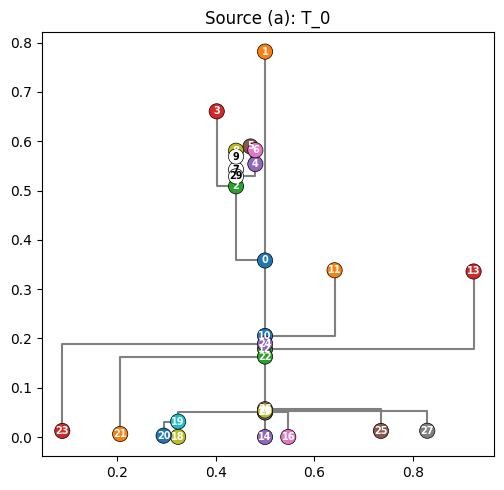

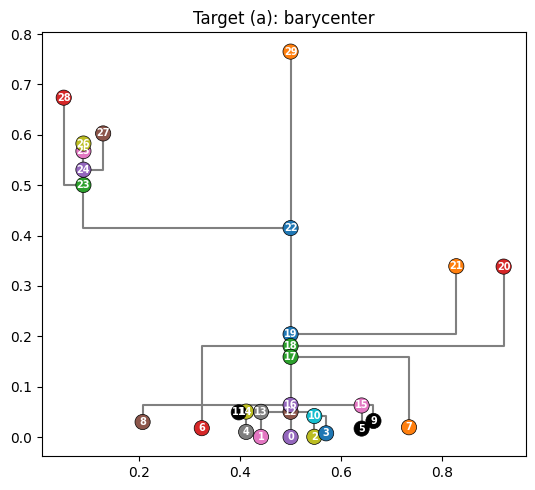

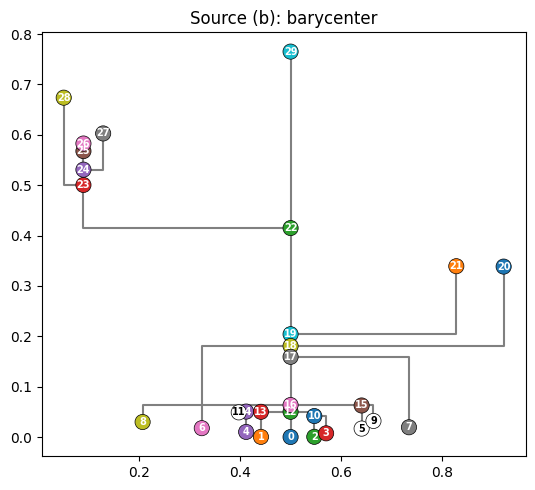

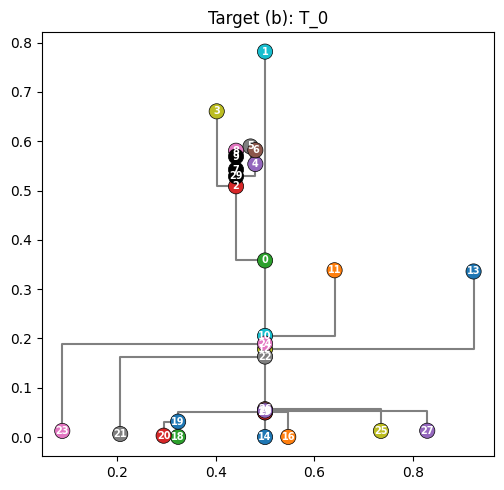

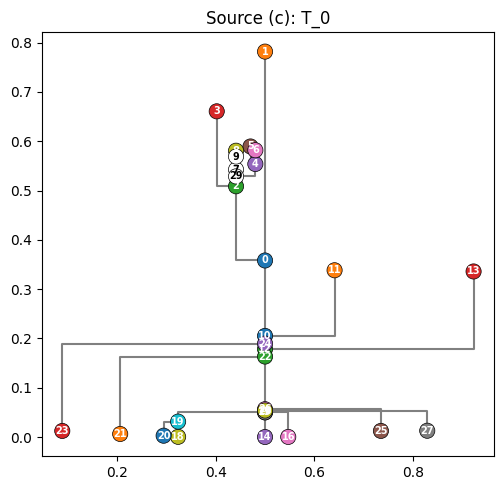

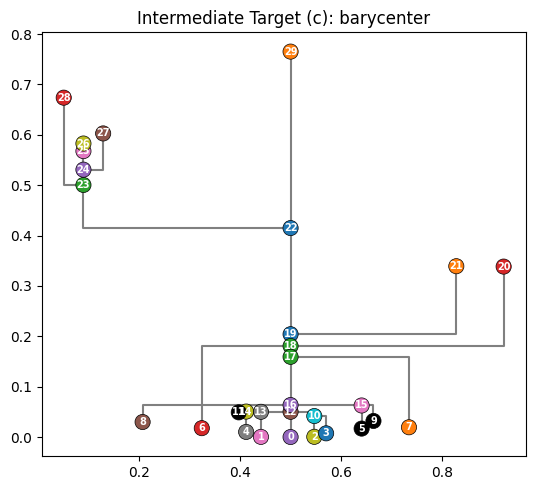

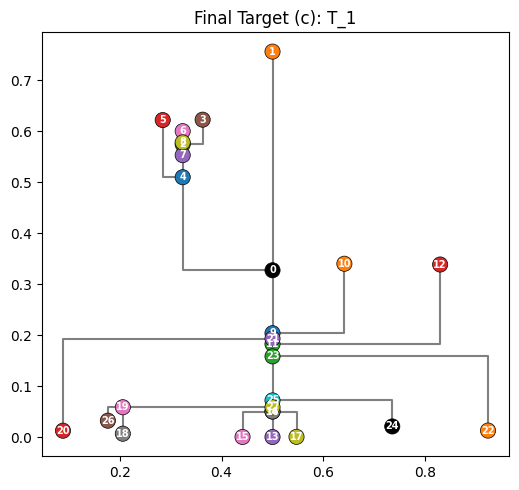

In [26]:
import importlib
import lib.contour_tree_visualization as ctv
import lib.color_transfer as ct

importlib.reload(ctv)
importlib.reload(ct)

# 4.3.3) Run pipeline (pass T1, T2 to skip recomputation)
result = ct.color_transfer_pipeline(
    x_1=x_1, x_2=x_2,
    Gs=Gs_sources, Cs=Cs, Ys=Ys, nodes_list=nodes_list,
    C_center=C_center, X_center=X_center,
    G_center=G_center,
    C_center_tree=C_center_tree, X_center_tree=X_center_tree,
    nodes_order_center=nodes_order_center,
    p_source=ps, p_center=p_center_tree,
    Lambda_list=Lambda_list,
    alpha=alpha_fgw,
    color_mode="categorical",
    color_attr="type",
    sequential_order="(x,y)",
    threshold=0.01,
    T1=T1, T2=T2,  # use precomputed couplings (from tree matrices)
    figsize=(14, 5),
    pie_size=0.015,
)
plt.show()

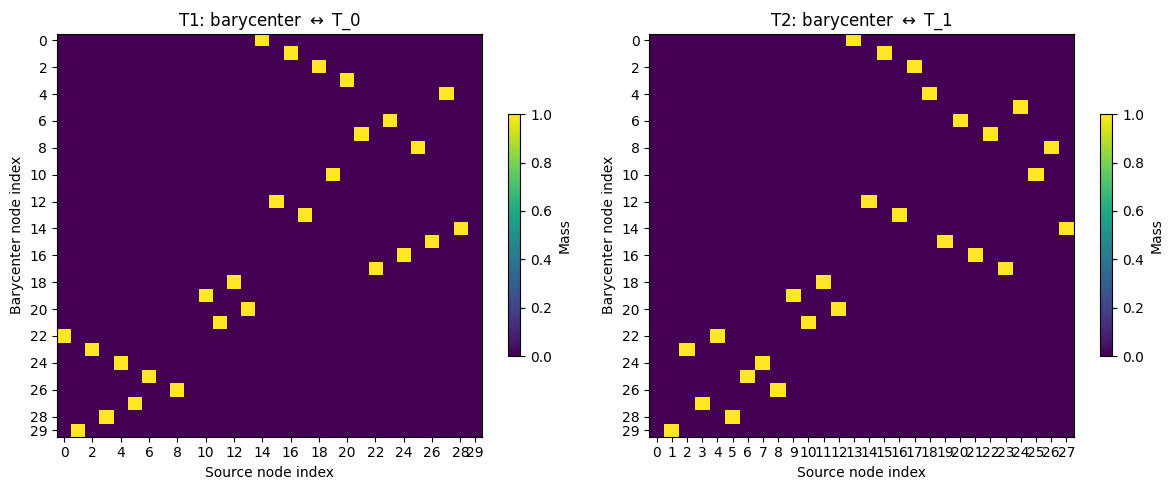

In [27]:
# 4.3.4) Heatmap of coupling matrices T1 and T2
def plot_coupling_heatmap(T, ax, title, max_ticks=15):
    """Plot heatmap of coupling T with readable axis indices."""
    T = np.asarray(T)
    n_row, n_col = T.shape
    im = ax.imshow(T, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_title(title)
    # x-axis: column indices (skip for readability)
    step_x = max(1, n_col // max_ticks)
    ticks_x = list(range(0, n_col, step_x))
    if n_col > 0 and (n_col - 1) not in ticks_x:
        ticks_x.append(n_col - 1)
    ax.set_xticks(ticks_x)
    ax.set_xticklabels(ticks_x)
    ax.set_xlabel("Source node index")
    # y-axis: row indices (skip for readability)
    step_y = max(1, n_row // max_ticks)
    ticks_y = list(range(0, n_row, step_y))
    if n_row > 0 and (n_row - 1) not in ticks_y:
        ticks_y.append(n_row - 1)
    ax.set_yticks(ticks_y)
    ax.set_yticklabels(ticks_y)
    ax.set_ylabel("Barycenter node index")
    plt.colorbar(im, ax=ax, shrink=0.6, label="Mass")

fig_h, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_coupling_heatmap(result["T1"], ax1, f"T1: barycenter $\\leftrightarrow$ T_{x_1}")
plot_coupling_heatmap(result["T2"], ax2, f"T2: barycenter $\\leftrightarrow$ T_{x_2}")
plt.tight_layout()
plt.show()

In [28]:
# print(Ys[x_1][18])
# print(Ys[x_1][20])
print(Ys[x_1][0])
print(Ys[x_1][2])

# print(X_center_tree[2])
# print(X_center_tree[3])
# print(X_center_tree[14])
print(X_center_tree[22])
print(X_center_tree[23])

[0.33091958 0.69192276 0.         0.45802132 0.         0.70710678
 0.        ]
[0.30584991 0.56657443 0.         0.65053968 0.         0.70710678
 0.        ]
[3.16467655e-01 6.70687276e-01 0.00000000e+00 5.30614941e-01
 7.71555428e-17 7.07106781e-01 5.68991656e-17]
[3.12447195e-01 5.75018950e-01 0.00000000e+00 6.40120132e-01
 4.87013491e-17 7.07106781e-01 3.14735450e-17]


In [29]:
def _pfgw_cost(C_i, X_i, p_i, C_tmp, X_tmp, p_tmp, T, lambda_penalty, alpha):
    M_s = dist(X_tmp, X_i)
    d, penalty = PFGW_dist_with_penalty(M_s, C_tmp, C_i, T, p_tmp, p_i, lambda_penalty, alpha=alpha)
    return d, penalty

print(_pfgw_cost(Cs[x_1], Ys[x_1], ps[x_1], C_center_tree, X_center_tree, p_center_tree, result['T1'], 0.2, 0.1))
manual_T1 = result['T1'].copy()
manual_T1[3, 20] = 1
manual_T1[14, 20] = 0
print(_pfgw_cost(Cs[x_1], Ys[x_1], ps[x_1], C_center_tree, X_center_tree, p_center_tree, manual_T1, 0.2, 0.1))


(np.float64(0.7624781447863889), np.float64(68.4))
(np.float64(0.7624781447863889), np.float64(68.4))


## 4.4 Compare Barycenter Graph vs Barycenter Tree (Can Be Skipped)

**This module only includes intermediate results and can be skipped.**

Compare the PFGW barycenter graph (G_center_graph) with the postprocessed barycenter tree (G_center):
1. Visualize C_center (restricted to tree nodes, reordered) and C_center_tree
2. Compute PFGW coupling between (X_center, C_center, p) and (X_center_tree, C_center_tree, p_center_tree)

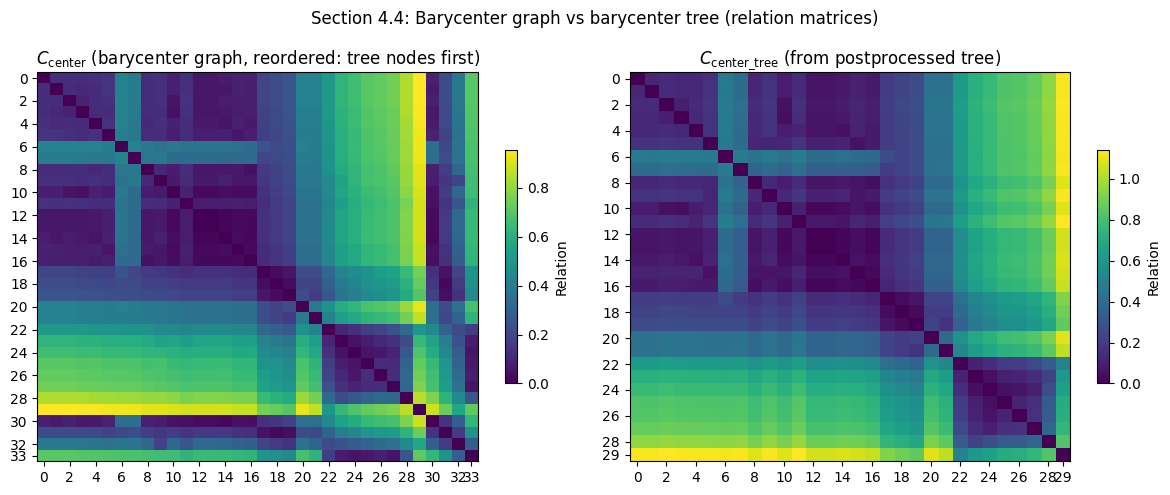

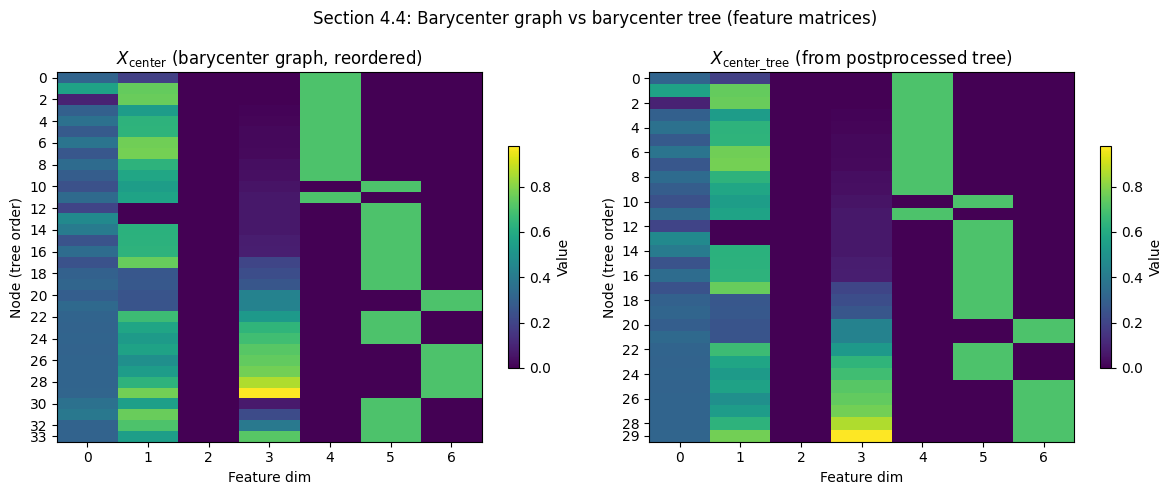

PFGW coupling (full barycenter graph -> barycenter tree):
  T shape: (34, 30)
  PFGW distance: 0.174225, penalty: 102.400000
  Mass transported: 30.000000


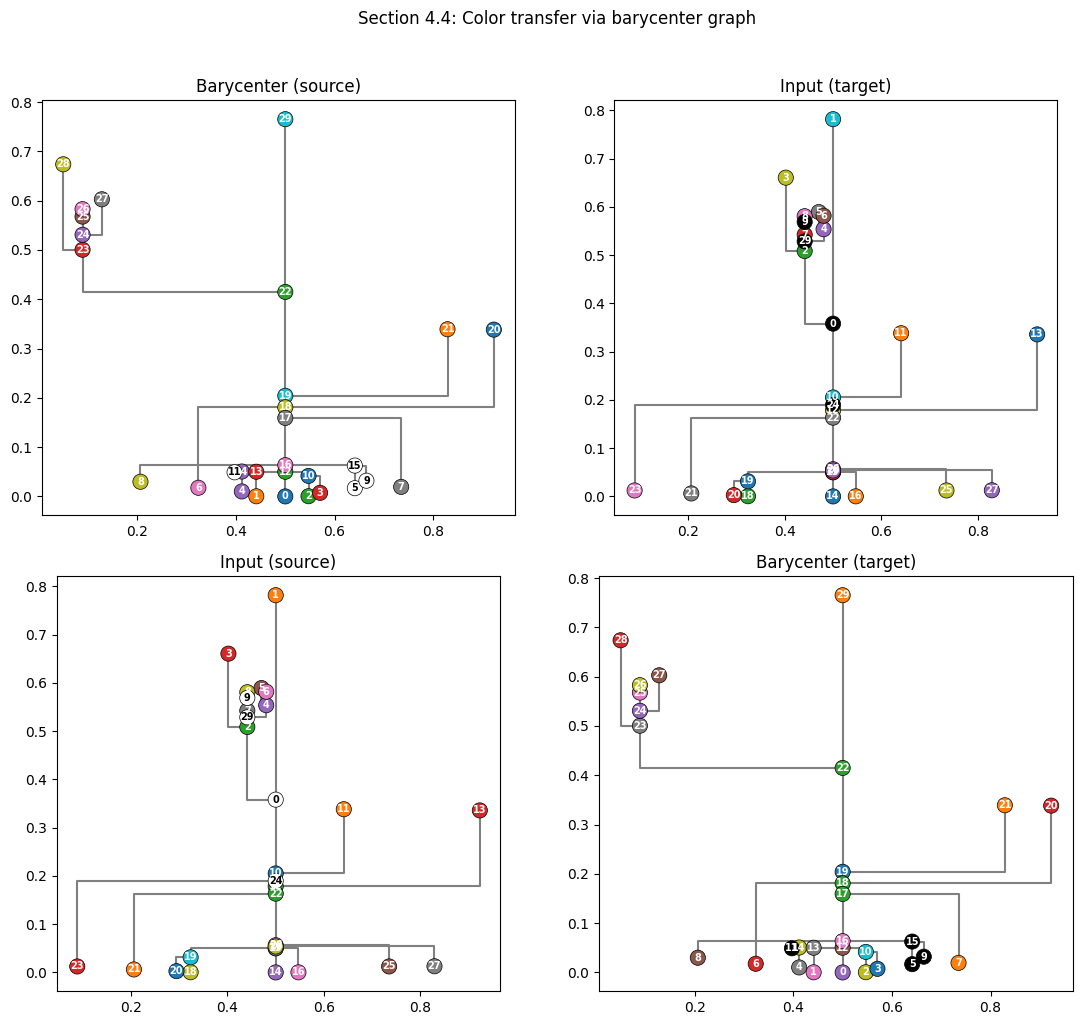

In [30]:
# 4.4) Compare barycenter graph (C_center) vs barycenter tree (C_center_tree)
# Run after Section 4.3.1 (uses C_center_tree, X_center_tree, p_center_tree, nodes_order_old).
from lib.gromov import partial_fused_gromov_ver1, PFGW_dist_with_penalty
from ot.utils import dist

if X_center is None:
    print("X_center is None (GW barycenter). Skipping Section 4.4.")
else:
    # 1) Reorder C_center: tree nodes first (nodes_order_old), then remaining graph nodes
    N_center = C_center.shape[0]
    tree_set = set(nodes_order_old)
    perm = list(nodes_order_old) + [i for i in range(N_center) if i not in tree_set]
    C_center_reordered = C_center[np.ix_(perm, perm)]

    # 2) Visualize barycenter graph matrix (reordered) and C_center_tree
    def plot_C_heatmap(C, ax, title, max_ticks=15):
        C = np.asarray(C)
        n = C.shape[0]
        im = ax.imshow(C, aspect="auto", cmap="viridis", interpolation="nearest")
        ax.set_title(title)
        step = max(1, n // max_ticks)
        ticks = list(range(0, n, step))
        if n > 0 and (n - 1) not in ticks:
            ticks.append(n - 1)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(ticks)
        ax.set_yticklabels(ticks)
        plt.colorbar(im, ax=ax, shrink=0.6, label="Relation")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    plot_C_heatmap(C_center_reordered, ax1, r"$C_{\mathrm{center}}$ (barycenter graph, reordered: tree nodes first)")
    plot_C_heatmap(C_center_tree, ax2, r"$C_{\mathrm{center\_tree}}$ (from postprocessed tree)")
    plt.suptitle("Section 4.4: Barycenter graph vs barycenter tree (relation matrices)")
    plt.tight_layout()
    plt.show()

    # 2b) Visualize X_center (reordered) and X_center_tree
    X_center_reordered = X_center[perm]
    def plot_X_heatmap(X, ax, title, max_ticks=15):
        X = np.asarray(X)
        n_row, n_col = X.shape
        im = ax.imshow(X, aspect="auto", cmap="viridis", interpolation="nearest")
        ax.set_title(title)
        step_r = max(1, n_row // max_ticks)
        step_c = max(1, n_col // max_ticks)
        ticks_r = list(range(0, n_row, step_r))
        ticks_c = list(range(0, n_col, step_c))
        if n_row > 0 and (n_row - 1) not in ticks_r:
            ticks_r.append(n_row - 1)
        if n_col > 0 and (n_col - 1) not in ticks_c:
            ticks_c.append(n_col - 1)
        ax.set_xticks(ticks_c)
        ax.set_yticks(ticks_r)
        ax.set_xticklabels(ticks_c)
        ax.set_yticklabels(ticks_r)
        ax.set_xlabel("Feature dim")
        ax.set_ylabel("Node (tree order)")
        plt.colorbar(im, ax=ax, shrink=0.6, label="Value")

    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))
    plot_X_heatmap(X_center_reordered, ax3, r"$X_{\mathrm{center}}$ (barycenter graph, reordered)")
    plot_X_heatmap(X_center_tree, ax4, r"$X_{\mathrm{center\_tree}}$ (from postprocessed tree)")
    plt.suptitle("Section 4.4: Barycenter graph vs barycenter tree (feature matrices)")
    plt.tight_layout()
    plt.show()

    # 3) PFGW coupling between barycenter GRAPH (full) and barycenter TREE
    #    Use full graph (not restricted) so we can reuse log["T"] for color transfer.
    Lambda_44 = lambda_penalty
    M_44_graph_tree = dist(X_center, X_center_tree)
    T_graph_tree = partial_fused_gromov_ver1(
        M_44_graph_tree, C_center, C_center_tree,
        p, p_center_tree,
        Lambda=Lambda_44, alpha=alpha_fgw,
        numItermax_gw=1000, tol=1e-7,
    )
    T_graph_tree = np.asarray(T_graph_tree, dtype=float)
    dist_val, penalty = PFGW_dist_with_penalty(
        M_44_graph_tree, C_center, C_center_tree,
        T_graph_tree, p, p_center_tree,
        Lambda_44, alpha=alpha_fgw,
    )
    print("PFGW coupling (full barycenter graph -> barycenter tree):")
    print(f"  T shape: {T_graph_tree.shape}")
    print(f"  PFGW distance: {dist_val:.6f}, penalty: {penalty:.6f}")
    print(f"  Mass transported: {T_graph_tree.sum():.6f}")

    # 4) Color transfer via barycenter graph (both directions)
    # Reuse log["T"][s] = coupling(barycenter_graph, input) from barycenter computation.
    from lib.color_transfer import (
        transfer_colors_via_coupling,
        assign_source_colors,
        _mask_unmatched_source_colors,
    )
    from lib.contour_tree_visualization import plot_contour_tree
    s_input = x_1  # input tree index (0, 1, ... into idx_list)
    T_graph_input = log["T"][s_input]  # (N_center_full, n_input) = coupling(barycenter_graph, input)

    # Direction 1: barycenter tree -> input via graph. Final coupling = T_graph_tree.T @ T_graph_input
    T_tree_to_input = T_graph_tree.T @ T_graph_input  # (N_tree, n_input)
    # For transfer: source=tree, target=input. Need (n_input, N_tree) with [i,j]=mass from tree j to input i
    T_for_tree_to_input = T_tree_to_input.T  # (n_input, N_tree)
    # Direction 2: input -> barycenter tree via graph. Coupling = T_graph_input.T @ T_graph_tree
    T_input_to_tree = T_graph_input.T @ T_graph_tree  # (n_input, N_tree)
    # For transfer: source=input, target=tree. Need (N_tree, n_input) with [i,j]=mass from input j to tree i
    T_for_input_to_tree = T_input_to_tree.T  # (N_tree, n_input)

    # Assign source colors
    G_input = Gs[idx_list[s_input]]
    nodes_input = nodes_list[s_input]
    _, colors_input = assign_source_colors(G_input, nodes_input, mode="categorical")
    _, colors_tree = assign_source_colors(G_center, nodes_order_center, mode="categorical")

    # Transfer: barycenter tree -> input
    target_colors_1, use_pie_1 = transfer_colors_via_coupling(
        colors_tree, ps[s_input], T_for_tree_to_input, "source_to_target", threshold=0.01, match_threshold=0.01
    )
    # Transfer: input -> barycenter tree
    target_colors_2, use_pie_2 = transfer_colors_via_coupling(
        colors_input, p_center_tree, T_for_input_to_tree, "source_to_target", threshold=0.01, match_threshold=0.01
    )

    # Mask unmatched source nodes (white) for display
    colors_tree_masked = _mask_unmatched_source_colors(
        colors_tree, T_for_tree_to_input, "source_to_target", match_threshold=0.01
    )
    colors_input_masked = _mask_unmatched_source_colors(
        colors_input, T_for_input_to_tree, "source_to_target", match_threshold=0.01
    )

    # Visualize both directions using plot_contour_tree
    nc_d1_left = {n: colors_tree_masked[i] for i, n in enumerate(nodes_order_center)}
    nc_d1_right = {n: target_colors_1[i] for i, n in enumerate(nodes_input)}
    nc_d2_left = {n: colors_input_masked[i] for i, n in enumerate(nodes_input)}
    nc_d2_right = {n: target_colors_2[i] for i, n in enumerate(nodes_order_center)}
    fig, ((ax1a, ax1b), (ax2a, ax2b)) = plt.subplots(2, 2, figsize=(12, 10))
    up_d1_right = [use_pie_1[nodes_input.index(n)] if n in nodes_input else False for n in G_input.nodes()]
    up_d2_right = [use_pie_2[nodes_order_center.index(n)] if n in nodes_order_center else False for n in G_center.nodes()]
    plot_contour_tree(
        [G_center, G_input],
        ax=[ax1a, ax1b],
        node_colors=[nc_d1_left, nc_d1_right],
        use_pie=[[False] * G_center.number_of_nodes(), up_d1_right],
        pie_size=0.015,
        title=["Barycenter (source)", "Input (target)"],
    )
    plot_contour_tree(
        [G_input, G_center],
        ax=[ax2a, ax2b],
        node_colors=[nc_d2_left, nc_d2_right],
        use_pie=[[False] * G_input.number_of_nodes(), up_d2_right],
        pie_size=0.015,
        title=["Input (source)", "Barycenter (target)"],
    )
    fig.suptitle("Section 4.4: Color transfer via barycenter graph", y=1.02)
    plt.tight_layout()
    plt.show()

In [31]:
# 5) Plot ALL input trees with colors transferred from barycenter tree
# Switch: "via_graph" = barycenter tree -> graph -> input; "direct" = barycenter tree -> input
COUPLING_MODE = "direct"  # or "direct"
from lib.color_transfer import compute_coupling_source_barycenter
input_trees = [Gs[idx_list[s]] for s in range(len(idx_list))]
nc_all = []
up_all = []
for s in range(len(idx_list)):
    if COUPLING_MODE == "via_graph":
        T_s = log["T"][s]
        T_tree_to_s = T_graph_tree.T @ T_s
        T_for_s = T_tree_to_s.T
    else:
        Lambda_s = Lambda_list[s] if Lambda_list is not None else lambda_penalty
        T_direct = compute_coupling_source_barycenter(
            s, C_center_tree, X_center_tree, Cs[s], Ys[s],
            p_center_tree, ps[s], Lambda=Lambda_s, alpha=alpha_fgw,
            numItermax=1000, tol=1e-7,
        )
        T_for_s = np.asarray(T_direct, dtype=float).T
    tc_s, up_s = transfer_colors_via_coupling(
        colors_tree, ps[s], T_for_s, "source_to_target", threshold=0.01, match_threshold=0.01
    )
    nodes_s = nodes_list[s]
    nc_all.append({n: tc_s[i] for i, n in enumerate(nodes_s)})
    up_all.append([up_s[nodes_s.index(n)] if n in nodes_s else False for n in input_trees[s].nodes()])
plot_contour_tree(
    input_trees,
    node_colors=nc_all,
    use_pie=up_all,
    pie_size=0.015,
    title=[f"Input {s} (colors from barycenter)" for s in range(len(idx_list))],
)
mode_str = "via graph" if COUPLING_MODE == "via_graph" else "direct"
plt.suptitle(f"All input trees with colors from barycenter ({mode_str})", y=1.02)
plt.tight_layout()
plt.show()

c:\Users\mingz\anaconda3\envs\pOTbarycenter\Lib\site-packages\ot\bregman\_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Computed 23 direct couplings (barycenter tree <-> input trees)
Ignored counts per barycenter node: [ 0  0  0  2 10  3  0  0  0 15  0 18  0  0  0  0  0  0  0  0  0  0  0  0
  2  2  3  9  3  0]
Nodes never ignored: 20/30
Nodes ignored at least once: 10/30


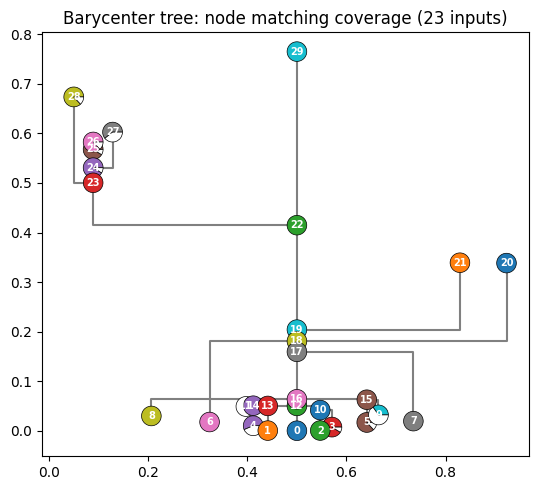

In [32]:
# 6) Barycenter tree with "ignored-in-matching" pie charts
# For each direct coupling (barycenter tree <-> input tree), a barycenter node is
# "ignored" if its row sum falls below the match threshold. Nodes with any ignores
# are drawn as pie charts: (original_color, matched/total) + (white, ignored/total).

from lib.color_transfer import (
    compute_coupling_source_barycenter,
    assign_source_colors,
    _draw_pie_at,
    _draw_single_contour_tree,
    _parse_order_spec,
    _add_sequential_colorbar,
)
from lib.contour_tree_visualization import contour_tree_layout
from matplotlib.collections import LineCollection

n_inputs = len(idx_list)
match_threshold = 0.01

# Compute all direct couplings (barycenter tree <-> each input tree)
T_all = []
for s in range(n_inputs):
    Lambda_s = Lambda_list[s] if Lambda_list is not None else lambda_penalty
    T_s = compute_coupling_source_barycenter(
        s, C_center_tree, X_center_tree, Cs[s], Ys[s],
        p_center_tree, ps[s], Lambda=Lambda_s, alpha=alpha_fgw,
        numItermax=1000, tol=1e-7,
    )
    T_all.append(np.asarray(T_s, dtype=float))
print(f"Computed {len(T_all)} direct couplings (barycenter tree <-> input trees)")

# Count how many times each barycenter node is "ignored" across all couplings
N_bary = len(nodes_order_center)
n_ignored = np.zeros(N_bary, dtype=int)

for T_s in T_all:
    total = float(T_s.sum())
    masses = T_s.sum(axis=1)  # row sums = mass per barycenter node
    n_rows = T_s.shape[0]
    expected = total / n_rows if n_rows > 0 and total > 0 else 0.0
    min_valid = match_threshold * expected
    for i in range(N_bary):
        if masses[i] < min_valid:
            n_ignored[i] += 1

print(f"Ignored counts per barycenter node: {n_ignored}")
print(f"Nodes never ignored: {np.sum(n_ignored == 0)}/{N_bary}")
print(f"Nodes ignored at least once: {np.sum(n_ignored > 0)}/{N_bary}")

# Assign original colors to barycenter nodes (same scheme as Source (b) in Section 4.3.3)
color_mode_viz = "categorical"
color_attr_viz = "type"
sequential_order_viz = "(x,y)"
sequential_cmap_viz = "Spectral"

order_key_center = None
if color_mode_viz in ("sequential", "serial"):
    order_key_center = _parse_order_spec(sequential_order_viz, G_center)

seq_cmap = sequential_cmap_viz or "Spectral"
_, bary_colors_list = assign_source_colors(
    G_center, nodes_order_center, mode=color_mode_viz, attr=color_attr_viz,
    order_key=order_key_center,
    cmap=seq_cmap if color_mode_viz in ("sequential", "serial") else None,
)

# Build node colors: solid if never ignored, pie chart otherwise
node_colors_viz = []
use_pie_viz = []
for i in range(N_bary):
    if n_ignored[i] == 0:
        node_colors_viz.append(bary_colors_list[i])
        use_pie_viz.append(False)
    else:
        matched_frac = (n_inputs - n_ignored[i]) / n_inputs
        ignored_frac = n_ignored[i] / n_inputs
        node_colors_viz.append([
            (bary_colors_list[i], matched_frac),
            ("white", ignored_frac),
        ])
        use_pie_viz.append(True)

# Draw barycenter tree (identical layout to Source (b))
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
_draw_single_contour_tree(
    G_center, node_colors_viz, nodes_order_center,
    use_pie=use_pie_viz, ax=ax,
    title=f"Barycenter tree: node matching coverage ({n_inputs} inputs)",
    node_size=200, pie_size=0.02,
)
if color_mode_viz in ("sequential", "serial"):
    _add_sequential_colorbar(fig, ax, cmap_name=seq_cmap)
fig.tight_layout()
plt.show()

## 4.5) Save barycenter tree data for external visualization

Exports: layout, couplings (direct and/or via-graph), node orders, metadata.

Input-tree JSON for metro_viz: section 3.1 (before barycenter).

In [ ]:
# Exports: layout, couplings (direct and/or via-graph), node orders, metadata.
# Input-tree JSON for metro_viz: section 3.1 (before barycenter).
import os, json, pickle
import numpy as np

save_keyword = "_balanced_distribution" if balanced_distribution else ""
SAVE_DIR = os.path.join("barycenter_export", dataset_name + save_keyword)
SAVE_DIRECT = True        # save direct couplings (barycenter tree <-> input tree)
SAVE_VIA_GRAPH = True     # save via-graph couplings (barycenter tree -> graph -> input)

os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1) Barycenter tree: graph + layout ────────────────────────────────
from lib.contour_tree_visualization import contour_tree_layout, edge_segment_node_ids

pos, branches, edge_segments = contour_tree_layout(
    G_center,
    root=None,
    width=1.0,
    height_scale=1.0,
    apply_resolution_improvement=True,
    resolution_sigma_scale=0.5,
)

with open(os.path.join(SAVE_DIR, "G_center.pkl"), "wb") as f:
    pickle.dump(G_center, f)

pos_serializable = {str(k): [float(v[0]), float(v[1])] for k, v in pos.items()}
with open(os.path.join(SAVE_DIR, "layout_pos.json"), "w") as f:
    json.dump(pos_serializable, f, indent=2)

pos_array = np.array([pos[n] for n in nodes_order_center])
np.save(os.path.join(SAVE_DIR, "layout_pos.npy"), pos_array)

with open(os.path.join(SAVE_DIR, "branches.pkl"), "wb") as f:
    pickle.dump(branches, f)
with open(os.path.join(SAVE_DIR, "edge_segments.pkl"), "wb") as f:
    pickle.dump(edge_segments, f)

print("Saved barycenter tree graph + layout")

# ── 2) Couplings ──────────────────────────────────────────────────────
n_inputs = len(idx_list)

if SAVE_DIRECT:
    out_dir = os.path.join(SAVE_DIR, "couplings_direct")
    os.makedirs(out_dir, exist_ok=True)
    # Always recompute here: this cell re-runs contour_tree_layout above, so layout
    # can change while in-memory T_all from cell 24 still matches n_inputs — reusing
    # would then write stale couplings next to fresh layout_pos.* (metro looks out of sync).
    reuse_cell24_T_all = False  # set True only if you just ran cell 24 and did not change tree/marginals
    try:
        _reuse = T_all if reuse_cell24_T_all else []
        if len(_reuse) != n_inputs:
            raise ValueError("length mismatch or reuse disabled")
        print("Reusing precomputed direct couplings from cell 24")
    except (NameError, ValueError):
        from lib.color_transfer import compute_coupling_source_barycenter
        print("Computing direct couplings (barycenter tree <-> each input)...")
        T_all = []
        for s in range(n_inputs):
            Lambda_s = Lambda_list[s] if Lambda_list is not None else lambda_penalty
            T_s = compute_coupling_source_barycenter(
                s, C_center_tree, X_center_tree, Cs[s], Ys[s],
                p_center_tree, ps[s], Lambda=Lambda_s, alpha=alpha_fgw,
                numItermax=1000, tol=1e-7,
            )
            print(T_s[3, :])
            T_all.append(np.asarray(T_s, dtype=float))
    for s in range(n_inputs):
        np.save(os.path.join(out_dir, f"T_{s:02d}.npy"), T_all[s])
    print(f"  -> {n_inputs} files in {out_dir}/")

if SAVE_VIA_GRAPH:
    out_dir = os.path.join(SAVE_DIR, "couplings_via_graph")
    os.makedirs(out_dir, exist_ok=True)
    try:
        _T_gt = T_graph_tree  # from cell 22
        for s in range(n_inputs):
            T_graph_input = log["T"][s]
            T_via = _T_gt.T @ T_graph_input   # (N_tree, n_input)
            np.save(os.path.join(out_dir, f"T_{s:02d}.npy"), np.asarray(T_via, dtype=float))
        print(f"  -> {n_inputs} files in {out_dir}/")
    except NameError:
        print("  Skipped via-graph couplings: T_graph_tree not found (run cell 22 first)")

# ── 3) Node orders ────────────────────────────────────────────────────
with open(os.path.join(SAVE_DIR, "nodes_order_center.json"), "w") as f:
    json.dump([int(n) for n in nodes_order_center], f)

with open(os.path.join(SAVE_DIR, "nodes_order_old.json"), "w") as f:
    json.dump([int(n) for n in nodes_order_old], f)

nodes_list_serializable = []
for nl in nodes_list:
    nodes_list_serializable.append([int(n) for n in nl])
with open(os.path.join(SAVE_DIR, "nodes_list.json"), "w") as f:
    json.dump(nodes_list_serializable, f)

print("Saved node orders")

# ── 4) Metadata ───────────────────────────────────────────────────────
metadata = {
    "dataset_name": dataset_name,
    "n_inputs": n_inputs,
    "N_center": len(nodes_order_center),
    "alpha_fgw": float(alpha_fgw),
    "lambda_penalty": float(lambda_penalty),
    "Lambda_list": [float(l) for l in Lambda_list],
    "relation_kind": relation_kind,
    "attribute_mode": attribute_mode,
    "idx_list": [int(i) for i in idx_list],
    "unique_types": [int(t) for t in unique_types],
}
with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

# ── 5) Input tree JSON (vizPos, segments, branches) is exported in section 3.1 before barycenter.
# Re-run that cell if you need to refresh input_trees/ without re-running this save block.

# ── Summary ───────────────────────────────────────────────────────────
print(f"\nAll data saved to '{SAVE_DIR}/':")
for dirpath, dirnames, filenames in os.walk(SAVE_DIR):
    level = dirpath.replace(SAVE_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(dirpath)}/")
    for fname in sorted(filenames):
        fpath = os.path.join(dirpath, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"{indent}  {fname}  ({size_kb:.1f} KB)")

Saved barycenter tree graph + layout
Computing direct couplings (barycenter tree <-> each input)...
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [ ]:
# 4.5.1) Verify all saved data can be loaded correctly
import os, json, pickle
import numpy as np
import networkx as nx

LOAD_DIR = os.path.join("barycenter_export", dataset_name + save_keyword)
errors = []

# ── Graph ─────────────────────────────────────────────────────────────
with open(os.path.join(LOAD_DIR, "G_center.pkl"), "rb") as f:
    G_loaded = pickle.load(f)
assert isinstance(G_loaded, nx.Graph), "G_center is not a Graph"
assert G_loaded.number_of_nodes() == G_center.number_of_nodes(), "node count mismatch"
assert G_loaded.number_of_edges() == G_center.number_of_edges(), "edge count mismatch"
print(f"G_center: {G_loaded.number_of_nodes()} nodes, {G_loaded.number_of_edges()} edges  ✓")

# ── Layout (JSON) ────────────────────────────────────────────────────
with open(os.path.join(LOAD_DIR, "layout_pos.json"), "r") as f:
    pos_json = json.load(f)
assert len(pos_json) == G_loaded.number_of_nodes(), "pos JSON length mismatch"
print(f"layout_pos.json: {len(pos_json)} positions  ✓")

# ── Layout (numpy) ───────────────────────────────────────────────────
pos_np = np.load(os.path.join(LOAD_DIR, "layout_pos.npy"))
assert pos_np.shape == (G_loaded.number_of_nodes(), 2), f"pos array shape {pos_np.shape} unexpected"
print(f"layout_pos.npy: shape {pos_np.shape}  ✓")

# ── Branches & edge segments ─────────────────────────────────────────
with open(os.path.join(LOAD_DIR, "branches.pkl"), "rb") as f:
    branches_loaded = pickle.load(f)
with open(os.path.join(LOAD_DIR, "edge_segments.pkl"), "rb") as f:
    segs_loaded = pickle.load(f)
print(f"branches: {len(branches_loaded)} branches  ✓")
print(f"edge_segments: {len(segs_loaded)} segments  ✓")

# ── Node orders ──────────────────────────────────────────────────────
with open(os.path.join(LOAD_DIR, "nodes_order_center.json"), "r") as f:
    noc = json.load(f)
with open(os.path.join(LOAD_DIR, "nodes_order_old.json"), "r") as f:
    noo = json.load(f)
with open(os.path.join(LOAD_DIR, "nodes_list.json"), "r") as f:
    nl = json.load(f)
assert noc == [int(n) for n in nodes_order_center], "nodes_order_center mismatch"
assert noo == [int(n) for n in nodes_order_old], "nodes_order_old mismatch"
assert len(nl) == len(nodes_list), "nodes_list length mismatch"
print(f"nodes_order_center: {len(noc)} entries  ✓")
print(f"nodes_order_old: {len(noo)} entries  ✓")
print(f"nodes_list: {len(nl)} input orderings  ✓")

# ── Metadata ─────────────────────────────────────────────────────────
with open(os.path.join(LOAD_DIR, "metadata.json"), "r") as f:
    meta = json.load(f)
assert meta["N_center"] == len(noc)
assert meta["n_inputs"] == len(nl)
print(f"metadata: n_inputs={meta['n_inputs']}, N_center={meta['N_center']}  ✓")

# ── Couplings (direct) ───────────────────────────────────────────────
direct_dir = os.path.join(LOAD_DIR, "couplings_direct")
if os.path.isdir(direct_dir):
    n_direct = 0
    for s in range(meta["n_inputs"]):
        fpath = os.path.join(direct_dir, f"T_{s:02d}.npy")
        T_loaded = np.load(fpath)
        assert T_loaded.shape[0] == meta["N_center"], f"T_{s:02d} row count mismatch"
        assert T_loaded.shape[1] == len(nl[s]), f"T_{s:02d} col count mismatch"
        n_direct += 1
    print(f"couplings_direct: {n_direct} files, all shapes valid  ✓")
else:
    print("couplings_direct: not found (skipped)")

# ── Couplings (via-graph) ────────────────────────────────────────────
via_dir = os.path.join(LOAD_DIR, "couplings_via_graph")
if os.path.isdir(via_dir) and any(f.endswith(".npy") for f in os.listdir(via_dir)):
    n_via = 0
    for s in range(meta["n_inputs"]):
        fpath = os.path.join(via_dir, f"T_{s:02d}.npy")
        T_loaded = np.load(fpath)
        assert T_loaded.shape[0] == meta["N_center"], f"T_{s:02d} row count mismatch"
        assert T_loaded.shape[1] == len(nl[s]), f"T_{s:02d} col count mismatch"
        n_via += 1
    print(f"couplings_via_graph: {n_via} files, all shapes valid  ✓")
else:
    print("couplings_via_graph: not found or empty (skipped)")

# ── Input trees (scalar-field x, y, z per critical point) ────────────
it_dir = os.path.join(LOAD_DIR, "input_trees")
if os.path.isdir(it_dir):
    for s in range(meta["n_inputs"]):
        fpath = os.path.join(it_dir, f"tree_{s:02d}.json")
        with open(fpath, "r") as f:
            td = json.load(f)
        G_ex = Gs[idx_list[s]]
        nn = G_ex.number_of_nodes()
        assert "xs" in td and "ys" in td and "zs" in td, f"tree_{s:02d} missing xs/ys/zs"
        assert len(td["xs"]) == nn and len(td["ys"]) == nn and len(td["zs"]) == nn, (
            f"tree_{s:02d}: expected xs/ys/zs length {nn} (one entry per critical point)")
        assert "vizPos" in td, f"tree_{s:02d} missing vizPos (re-run export cell 7)"
        assert len(td["vizPos"]) == nn, (
            f"tree_{s:02d}: vizPos must have one entry per node ({nn})")
        if "vizEdgeSegments" in td or "vizSegmentNodeIds" in td:
            assert "vizEdgeSegments" in td and "vizSegmentNodeIds" in td, (
                f"tree_{s:02d}: vizEdgeSegments and vizSegmentNodeIds must both be present"
            )
            assert len(td["vizEdgeSegments"]) == len(td["vizSegmentNodeIds"]), (
                f"tree_{s:02d}: vizEdgeSegments vs vizSegmentNodeIds length mismatch"
            )
        if "branches" in td:
            assert isinstance(td["branches"], list) and len(td["branches"]) > 0, (
                f"tree_{s:02d}: branches must be a non-empty list when present"
            )
    print(f"input_trees: {meta['n_inputs']} files with vizPos  ✓")
else:
    print("input_trees: not found")

print("\nAll checks passed.")

G_center: 30 nodes, 29 edges  ✓
layout_pos.json: 30 positions  ✓
layout_pos.npy: shape (30, 2)  ✓
branches: 17 branches  ✓
edge_segments: 17 segments  ✓
nodes_order_center: 30 entries  ✓
nodes_order_old: 30 entries  ✓
nodes_list: 23 input orderings  ✓
metadata: n_inputs=23, N_center=30  ✓
couplings_direct: 23 files, all shapes valid  ✓
couplings_via_graph: 23 files, all shapes valid  ✓
input_trees: 23 files with vizPos  ✓

All checks passed.


In [35]:
for node in G_loaded.nodes():
    print(G_loaded.nodes[node])

{'x': np.float64(62.60869565217395), 'y': np.float64(126.2173913043479), 'z': np.float64(0.0), 'height': 0.6737183043478263, 'type': 2, 'type_features': [0.0, 0.0, 0.7071067811865476], 'type_mass': [0.0, 0.0, 1.0]}
{'x': np.float64(62.50000000000001), 'y': np.float64(112.16666666666667), 'z': np.float64(0.0), 'height': 0.5676057499999997, 'type': 2, 'type_features': [2.1286320780568001e-16, 2.999564880891878e-16, 0.7071067811865469], 'type_mass': [3.0103403540903517e-16, 4.242025335775332e-16, 0.9999999999999992]}
{'x': np.float64(62.31578947368423), 'y': np.float64(114.6842105263158), 'z': np.float64(0.0), 'height': 0.5004164736842107, 'type': 1, 'type_features': [4.870134906090112e-17, 0.7071067811865475, 3.147354503690846e-17], 'type_mass': [6.887410834779256e-17, 1.0, 4.4510314247156364e-17]}
{'x': np.float64(62.666666666666686), 'y': np.float64(106.27777777777779), 'z': np.float64(0.0), 'height': 0.5307932222222221, 'type': 1, 'type_features': [6.349427496918276e-17, 0.70710678118